In [1]:
!pip -q install torch torchvision matplotlib opencv-python

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

def create_edge_image(img):
    img_np = np.transpose(img.numpy(), (1, 2, 0))
    img_np = (img_np * 255).astype(np.uint8)

    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    edges = cv2.Canny(gray, 100, 200)

    edges = edges / 255.0
    edges = np.expand_dims(edges, axis=0)

    return torch.tensor(edges, dtype=torch.float)

class PairedDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, _ = self.dataset[idx]
        edge = create_edge_image(img)
        return edge, img

paired_dataset = PairedDataset(dataset)

train_loader = torch.utils.data.DataLoader(
    paired_dataset,
    batch_size=64,
    shuffle=True
)

print("Paired dataset size:", len(paired_dataset))

100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]


Paired dataset size: 50000


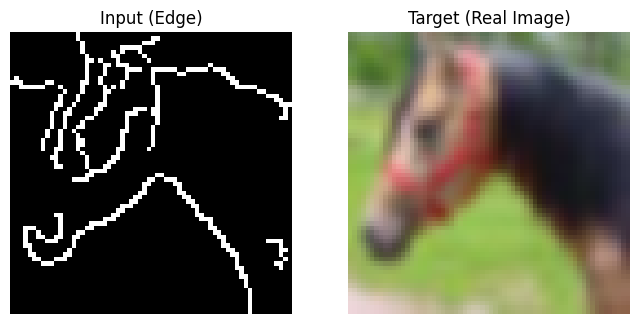

In [3]:
edge, real = next(iter(train_loader))

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.title("Input (Edge)")
plt.imshow(edge[0][0].cpu(), cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Target (Real Image)")
plt.imshow(np.transpose(real[0].cpu(), (1,2,0)))
plt.axis("off")

plt.show()

In [4]:
class UNetGenerator(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.down1 = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2)
        )

        self.down2 = nn.Sequential(
            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2)
        )

        self.down3 = nn.Sequential(
            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2)
        )

        # Decoder
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU()
        )

        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(256, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.up3 = nn.Sequential(
            nn.ConvTranspose2d(128, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(d1)
        d3 = self.down3(d2)

        u1 = self.up1(d3)
        u2 = self.up2(torch.cat([u1, d2], dim=1))
        u3 = self.up3(torch.cat([u2, d1], dim=1))

        return u3


generator = UNetGenerator().to(device)

In [5]:
class PatchDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(4, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2),

            nn.Conv2d(256, 1, 4, 1, 1)
        )

    def forward(self, x, y):
        inp = torch.cat([x, y], dim=1)
        return self.model(inp)


discriminator = PatchDiscriminator().to(device)

In [8]:
criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1 = nn.L1Loss()

optimizer_G = optim.Adam(generator.parameters(), lr=0.0002)
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002)

In [9]:
epochs = 10

for epoch in range(epochs):
    for i, (edge, real) in enumerate(train_loader):

        edge = edge.to(device)
        real = real.to(device)

        # Train Discriminator
        optimizer_D.zero_grad()

        fake = generator(edge)

        pred_real = discriminator(edge, real)
        loss_real = criterion_GAN(pred_real, torch.ones_like(pred_real))

        pred_fake = discriminator(edge, fake.detach())
        loss_fake = criterion_GAN(pred_fake, torch.zeros_like(pred_fake))

        loss_D = (loss_real + loss_fake) * 0.5
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()

        pred_fake = discriminator(edge, fake)
        loss_GAN = criterion_GAN(pred_fake, torch.ones_like(pred_fake))

        loss_L1 = criterion_L1(fake, real)

        loss_G = loss_GAN + 100 * loss_L1
        loss_G.backward()
        optimizer_G.step()

    print(f"Epoch [{epoch+1}/{epochs}] Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")

Epoch [1/10] Loss D: 0.0247, Loss G: 36.0668
Epoch [2/10] Loss D: 0.0241, Loss G: 29.8356
Epoch [3/10] Loss D: 0.0059, Loss G: 33.6642
Epoch [4/10] Loss D: 0.0029, Loss G: 36.6750
Epoch [5/10] Loss D: 0.0067, Loss G: 32.7301
Epoch [6/10] Loss D: 0.0135, Loss G: 30.4687
Epoch [7/10] Loss D: 0.0307, Loss G: 31.3211
Epoch [8/10] Loss D: 0.0106, Loss G: 31.2417
Epoch [9/10] Loss D: 0.0380, Loss G: 35.9569
Epoch [10/10] Loss D: 0.0068, Loss G: 33.4394


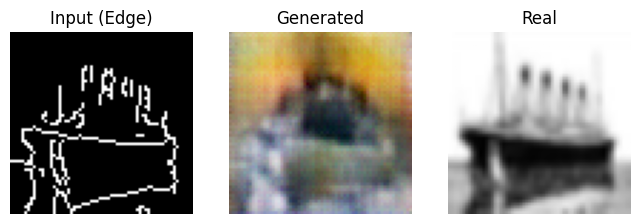

In [10]:
generator.eval()

with torch.no_grad():
    edge, real = next(iter(train_loader))
    edge = edge.to(device)
    fake = generator(edge)

plt.figure(figsize=(8,6))

plt.subplot(1,3,1)
plt.title("Input (Edge)")
plt.imshow(edge[0][0].cpu(), cmap="gray")
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Generated")
plt.imshow(np.transpose(fake[0].cpu(), (1,2,0)))
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Real")
plt.imshow(np.transpose(real[0].cpu(), (1,2,0)))
plt.axis("off")

plt.savefig("pix2pix_results.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
torch.save(generator.state_dict(), "pix2pix_generator.pth")
print("Model saved.")

Model saved.
